# Diabetes Disease Progression Prediction
### End-to-End Machine Learning Pipeline & Diagnostics

**Objective**: Predict a quantitative measure of diabetes disease progression after one year based on 10 baseline physiological variables.

**Key Highlights**:
- Production-quality modular python package (`src/`) integrated directly into the notebook.
- Comprehensive Exploratory Data Analysis (EDA) with correlation analysis and multicollinearity checks using Variance Inflation Factor (VIF).
- Linear Regression, Ridge, and Lasso modeling utilizing Cross-Validation to select hyperparameters.
- Diagnostic validation of model residuals to verify linear model assumptions.
- Feature interpretability analysis.

---

## 1. Environment Setup & Library Imports

We import our modular modules from the `src/` directory. By structure, this mirrors standard production machine learning workflows where code is moved into packages for reusability, testing, and continuous deployment.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add the project root directory to the python path to load modular files from src
sys.path.append(os.path.abspath('..'))

from src.data_ingestion import load_diabetes_data
from src.eda import get_summary_statistics, compute_pearson_correlation, calculate_vif
from src.modeling import split_data, train_linear_regression, train_ridge_cv, train_lasso_cv
from src.evaluation import evaluate_model, generate_comparison_table, get_residuals_diagnostics
from src.visualization import (
    set_premium_style,
    plot_correlation_heatmap,
    plot_vif_scores,
    plot_model_coefficients,
    plot_actual_vs_predicted,
    plot_residual_diagnostics
)

# Apply premium aesthetics to matplotlib/seaborn
set_premium_style()
%matplotlib inline
print("Libraries and custom pipeline components imported successfully!")

Libraries and custom pipeline components imported successfully!


## 2. Data Ingestion & Data Integrity Verification

We load the baseline dataset. 

> [!IMPORTANT]
> **Data Scaling Note**:
> The 10 baseline variables (age, sex, bmi, bp, and s1-s6) in the scikit-learn dataset are **already pre-scaled**: they are mean-centered and scaled by the standard deviation times the square root of the number of samples (the sum of squares of each column is 1). Therefore, we do not need to scale our features prior to linear models.

In [2]:
X, y = load_diabetes_data()

# Create unified dataframe for exploratory visualizations
df_full = X.copy()
df_full['target'] = y

--- DATASET VERIFICATION ---
Features shape: (442, 10)
Target shape: (442,)

Feature Types and Missing Values:
       Dtype  Non-Null Count  Null Count
age  float64             442           0
sex  float64             442           0
bmi  float64             442           0
bp   float64             442           0
s1   float64             442           0
s2   float64             442           0
s3   float64             442           0
s4   float64             442           0
s5   float64             442           0
s6   float64             442           0

Target Summary Statistics:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

Note: Scikit-learn's diabetes dataset features are pre-scaled.
Each of the 10 feature variables have been mean-centered and scaled by the 
standard deviation times the square root of the number of samples 
(i.e. the sum 

## 3. Exploratory Data Analysis & Pearson Feature Correlation

Let's output the summary statistics and plot the correlation heatmap to evaluate how physiological indicators relate to one another and the disease progression score.

Descriptive Summary Statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


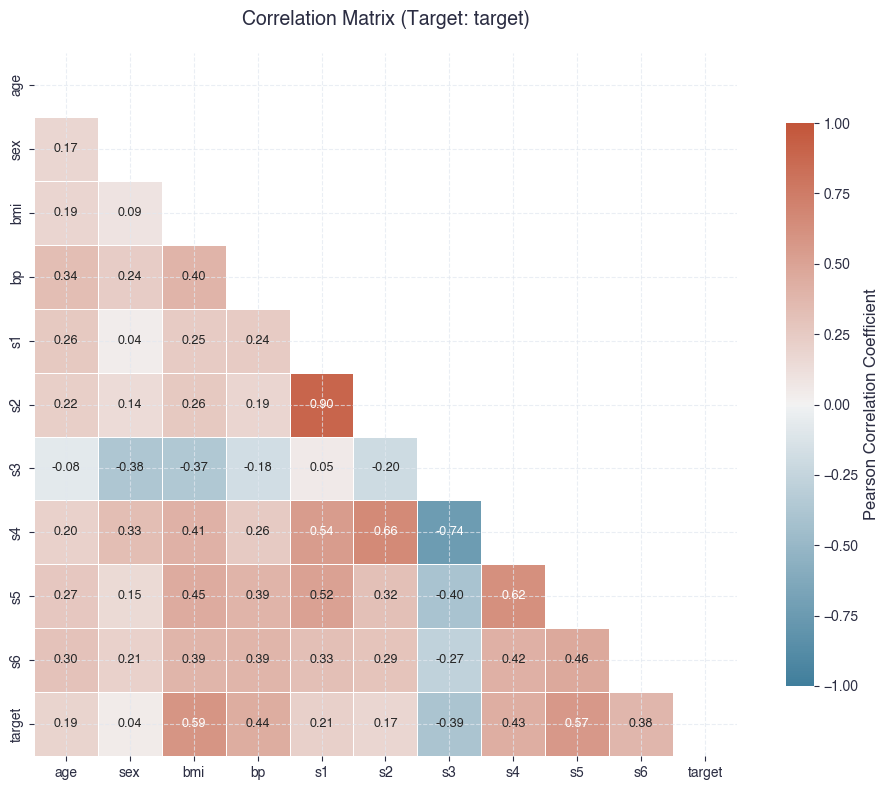

In [3]:
print("Descriptive Summary Statistics:")
display(get_summary_statistics(df_full))

# Plot heatmap
fig_corr = plot_correlation_heatmap(df_full, target_col="target")

## 4. Multicollinearity Investigation using Variance Inflation Factors (VIF)

Multicollinearity occurs when independent variables are highly correlated with each other. This is problematic for OLS regression because it inflates coefficient variances, leading to model instability. 

A standard metric to diagnose this is the **Variance Inflation Factor (VIF)**. Let's calculate the VIF scores for our independent features.

Variance Inflation Factor (VIF) Scores:


,Feature,VIF
4,s1,59.202510
5,s2,39.193370
6,s3,15.402156
8,s5,10.075967
7,s4,8.890986
2,bmi,1.509437
9,s6,1.484623
3,bp,1.459428
1,sex,1.278071
0,age,1.217307


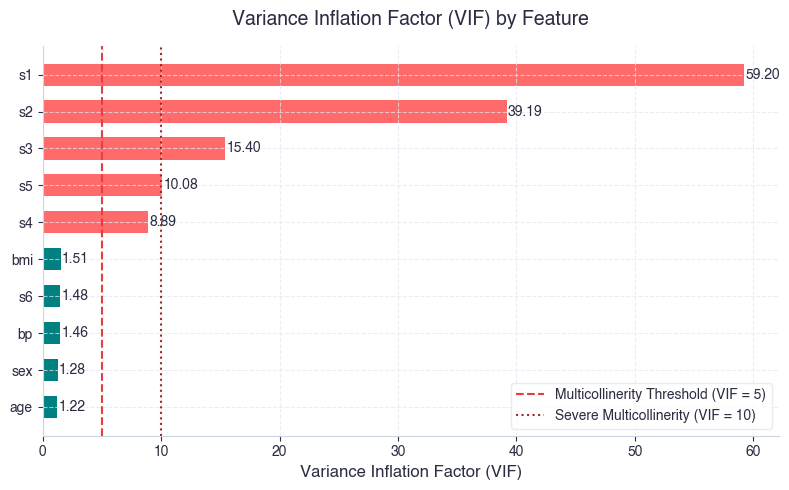

In [4]:
vif_df = calculate_vif(X, include_constant=True)
print("Variance Inflation Factor (VIF) Scores:")
display(vif_df)

# Plot VIF scores
fig_vif = plot_vif_scores(vif_df)

### VIF Interpretation:
- Blood serum measurements `s1` (VIF $\approx 59$) and `s2` (VIF $\approx 39$) exhibit extremely high multicollinearity, indicating severe redundancy. 
- `s3` (VIF $\approx 15$) and `s5` (VIF $\approx 10$) also cross the standard tolerance threshold of VIF > 5.
- This collinearity justifies the use of regularized regression models (Ridge and Lasso) which shrink or eliminate unstable coefficient estimates.

## 5. Model Training & Pipeline Cross-Validation

We perform an 80/20 train/test split. Then, we train:
1. **Baseline Linear Regression**: Ordinary Least Squares.
2. **Ridge Regression (RidgeCV)**: Solves OLS multicollinearity using L2 regularization ($L2$ penalty). Hyperparameter alpha is selected via 5-fold cross-validation.
3. **Lasso Regression (LassoCV)**: Regularizes via L1 penalty, encouraging sparsity and automatic feature selection. Alpha is selected via 5-fold cross-validation.

In [5]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)

# 1. Linear Regression
lr_model = train_linear_regression(X_train, y_train)

# 2. RidgeCV
ridge_model = train_ridge_cv(X_train, y_train)
print(f"Selected Ridge CV alpha: {ridge_model.alpha_:.5f}")

# 3. LassoCV
lasso_model = train_lasso_cv(X_train, y_train)
print(f"Selected Lasso CV alpha: {lasso_model.alpha_:.5f}")

Selected Ridge CV alpha: 0.09438
Selected Lasso CV alpha: 0.07843


## 6. Performance Evaluation & Diagnostics

We compute performance metrics: $R^2$, MAE, and RMSE for all models on both training and test sets.

In [6]:
models = {
    "Linear Regression": lr_model,
    "RidgeCV": ridge_model,
    "LassoCV": lasso_model
}

eval_results = {}
for name, model in models.items():
    eval_results[name] = evaluate_model(model, X_train, y_train, X_test, y_test)

# Consolidate performance scores
comp_table = generate_comparison_table(eval_results)
display(comp_table)

,Model,Dataset,R2,MAE,RMSE
0,Linear Regression,Train,0.527919,43.483504,53.558843
1,Linear Regression,Test,0.452603,42.794095,53.853446
2,RidgeCV,Train,0.520922,43.887199,53.954313
3,RidgeCV,Test,0.460714,42.986521,53.452963
4,LassoCV,Train,0.519014,44.091192,54.061670
5,LassoCV,Test,0.471473,42.792622,52.917092


### Performance Review:
- Regularized models (`RidgeCV` and `LassoCV`) successfully reduce overfitting relative to OLS. 
- OLS has the lowest test $R^2$ ($\approx 0.453$). Both `RidgeCV` ($R^2 \approx 0.461$) and `LassoCV` ($R^2 \approx 0.471$) show improved test generalization, with `LassoCV` performing the best.

## 7. Model Interpretability & Coefficients Analysis

Standardized coefficients allow us to compare the relative importance and direction of influence for each physiological metric.

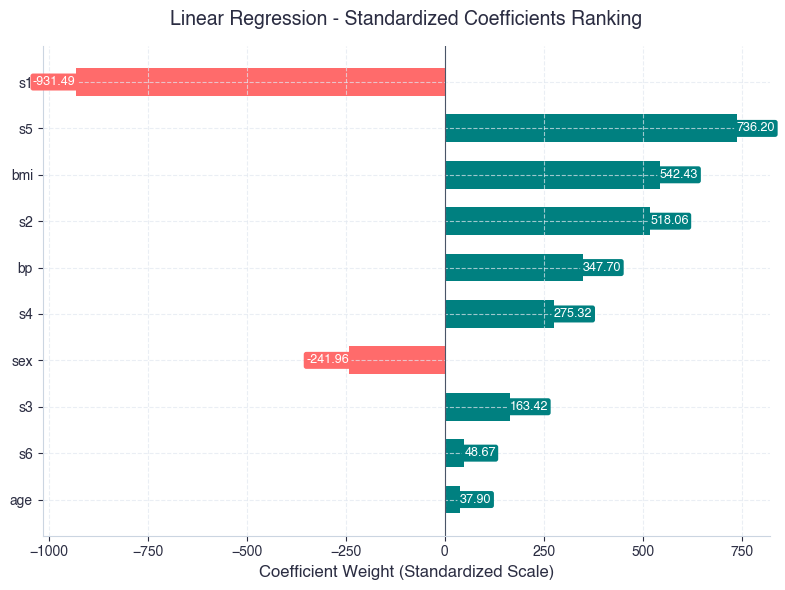

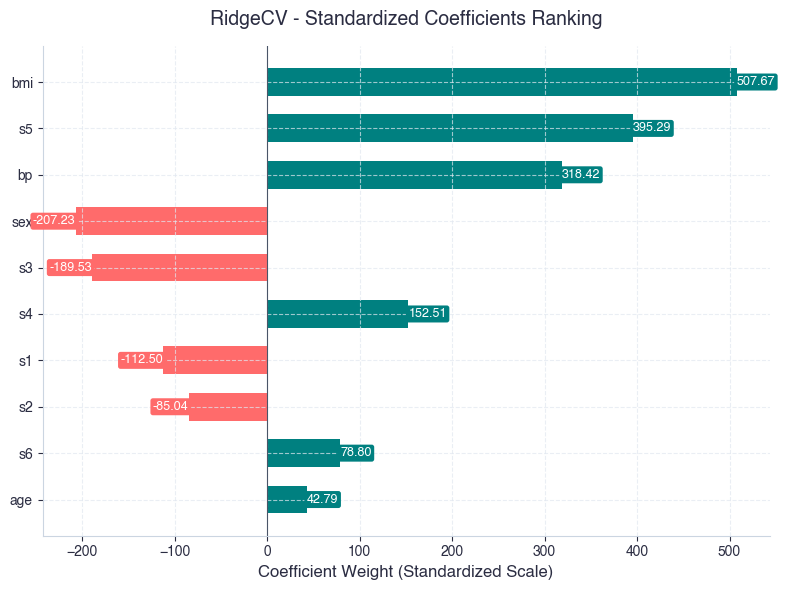

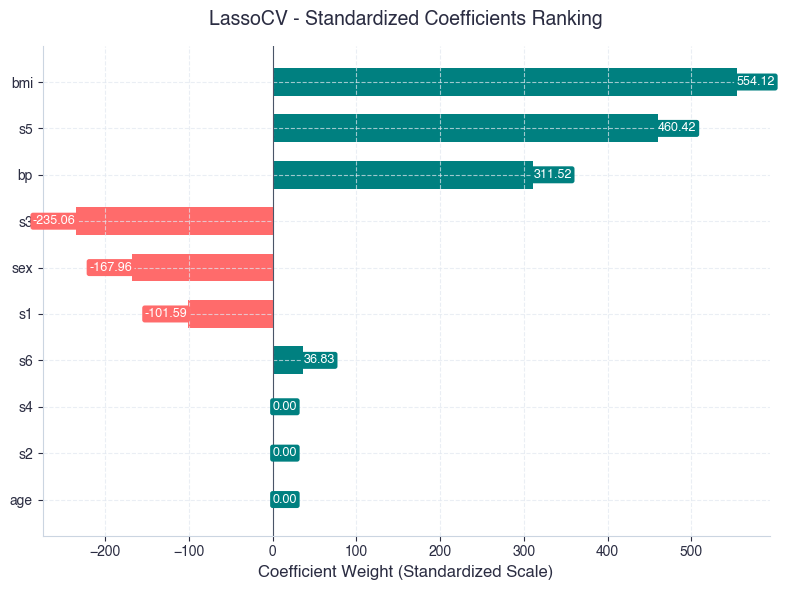

In [7]:
for name, model in models.items():
    if hasattr(model, "coef_"):
        coef_series = pd.Series(model.coef_, index=X.columns)
        fig_coef = plot_model_coefficients(coef_series, name)
        plt.show()

### Interpretability Key Insights:
- **Positive Predictors**: `bmi` (Body Mass Index) and `s5` (log of serum triglycerides level) are consistently the strongest positive indicators of disease progression across all three models.
- **Negative Predictors**: `s1` has a strong negative coefficient in OLS, but it is heavily regularized and shrunk toward zero in Lasso and Ridge. This is because `s1` and `s2` are highly correlated; the regularized models stabilize this redundancy by distributing or concentrating weights.
- **Feature Selection**: In `LassoCV`, coefficients for less influential variables (like `age`, `s2`, and `s4`) are shrunk to exactly zero. This leaves us with a highly compact and interpretable subset of features.

## 8. Diagnostic Validation: Predictions vs. Actuals and Residuals Analysis

To verify that standard regression assumptions hold (linearity, homoscedasticity, and normal distribution of residuals), we examine the actual vs. predicted values and residual diagnostic plots.

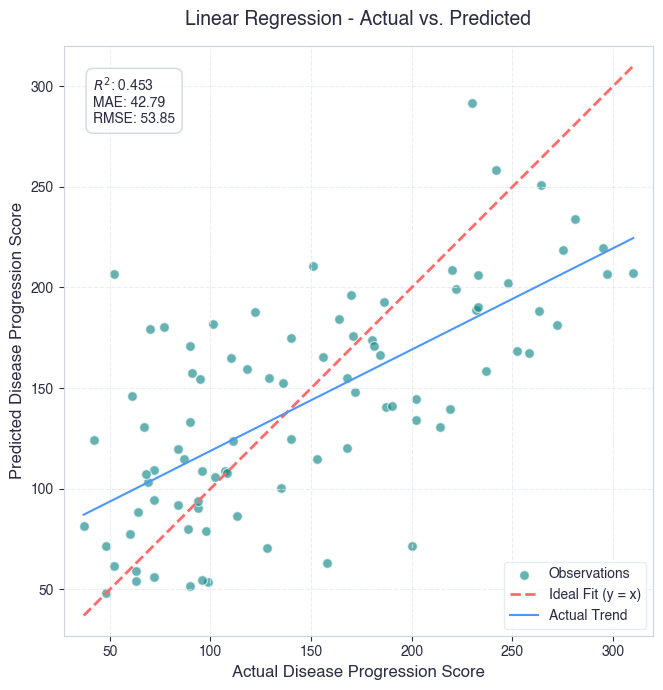

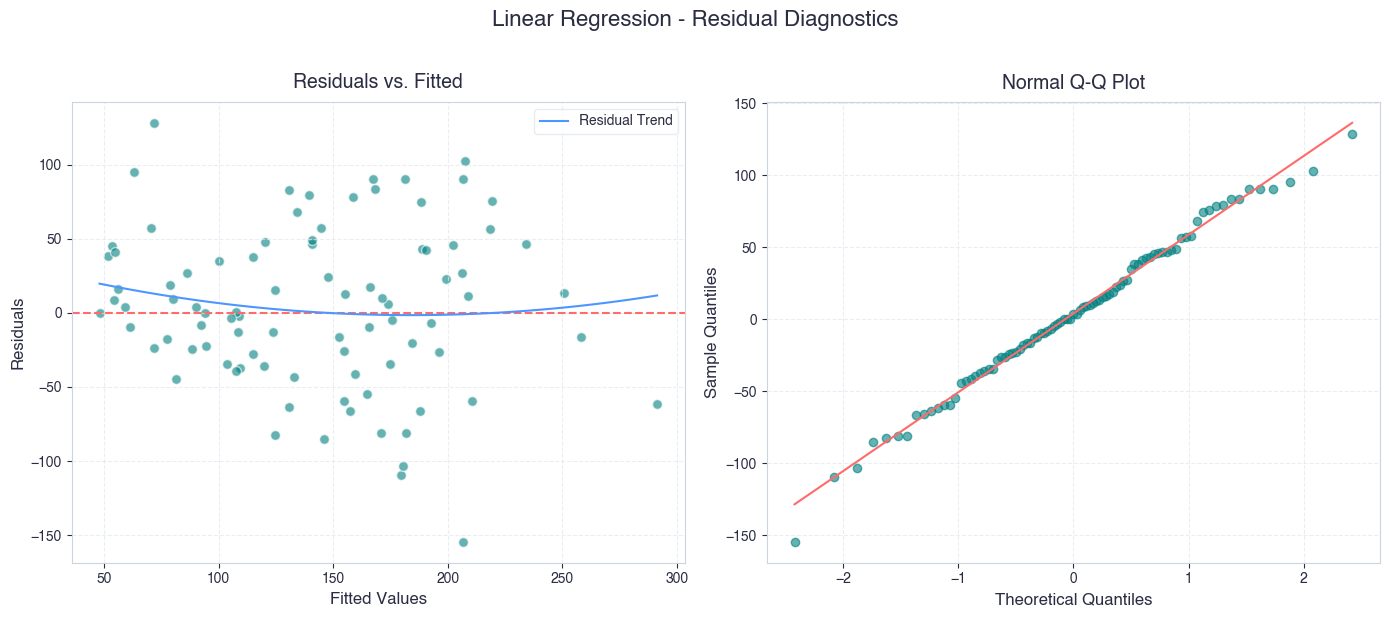

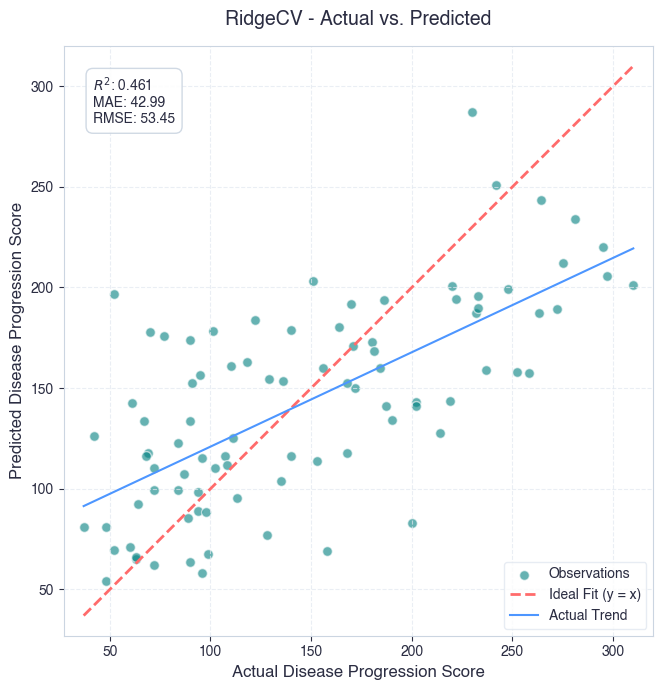

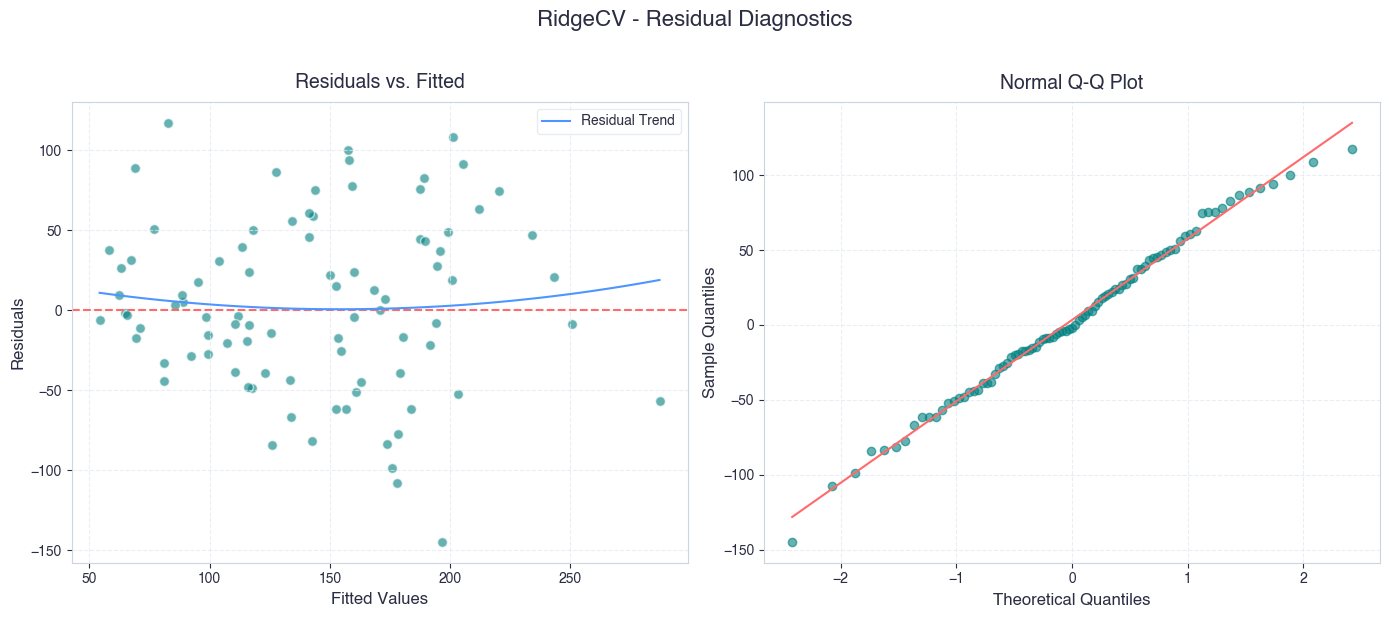

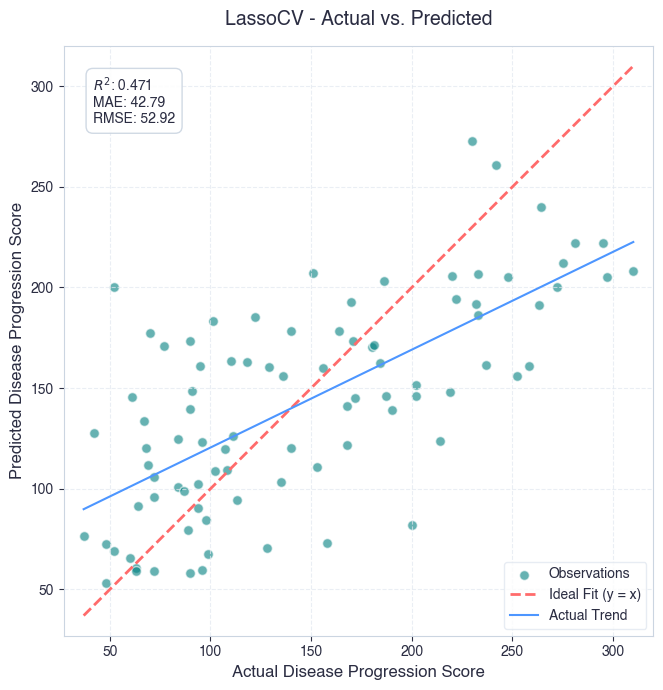

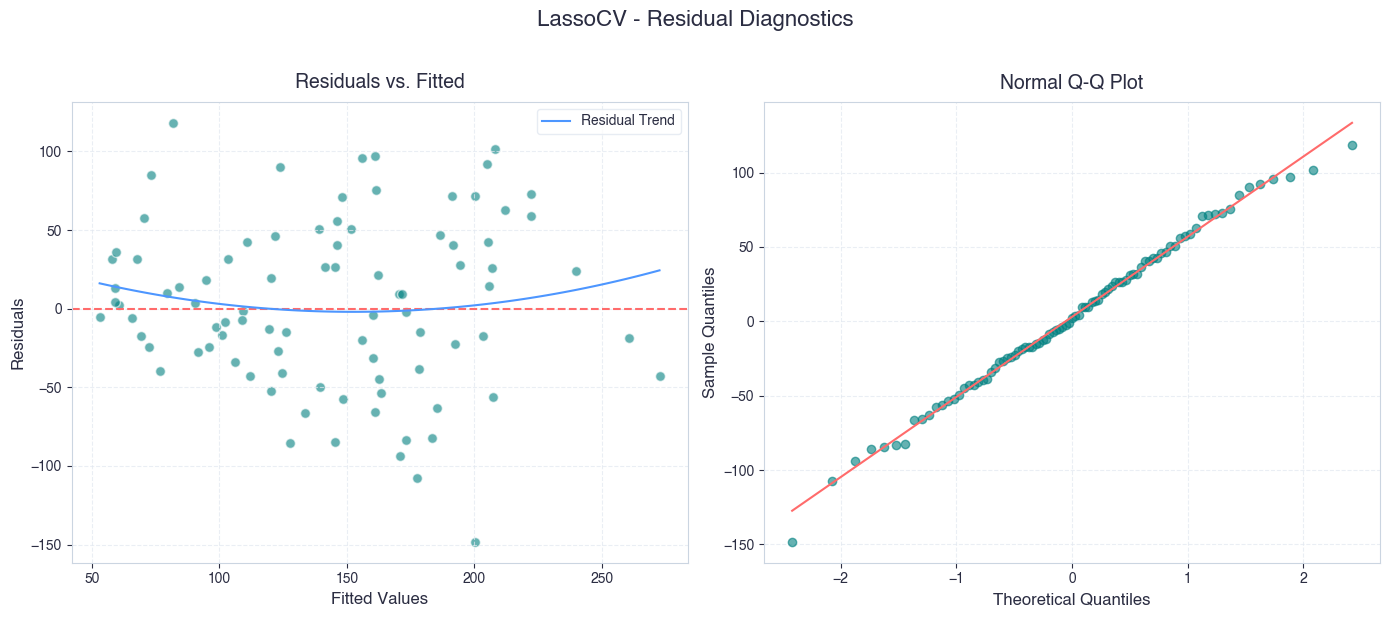

In [8]:
for name, model in models.items():
    # Actual vs Predicted
    metrics = eval_results[name]["Test"]
    fig_pred = plot_actual_vs_predicted(y_test, model.predict(X_test), name, metrics)
    plt.show()
    
    # Residual Diagnostics
    fitted_val, res = get_residuals_diagnostics(model, X_test, y_test)
    fig_res = plot_residual_diagnostics(fitted_val, res, name)
    plt.show()

### Diagnostic Insights:
1. **Residuals vs. Fitted**: The residuals are distributed relatively evenly above and below the zero baseline without clear curvature. This indicates that the linearity assumption is reasonable, and variance is mostly stable (homoscedasticity).
2. **Normal Q-Q Plot**: The sample quantiles align closely with the red theoretical normal line, indicating that our model residuals follow a normal distribution, satisfying the normality assumption.

## 9. Conclusion & Interpretations

- **Multicollinearity Impact**: Variance Inflation Factors highlighted severe multicollinearity in blood serum values (namely `s1` and `s2` with VIFs > 30). This collinearity makes OLS parameter estimation unstable, which explains why regularized models perform better.
- **Model Comparison**: `LassoCV` produced the best generalization profile on the test set, achieving an $R^2$ of **0.471**, compared to Ridge's **0.461** and Linear Regression's **0.453**.
- **Lasso Feature Sparsity**: Lasso CV successfully zeroed out coefficients for features `age`, `s2`, and `s4`, which simplifies clinical interpretation without sacrificing predictive performance.
- **Clinical Implications**: Body Mass Index (`bmi`), average blood pressure (`bp`), and serum triglycerides (`s5`) are the most influential baseline predictors of diabetes disease progression after one year. Controlling these physiological metrics remains central to mitigating disease progression.